### ```Netflix Data Analysis```

In [2]:
# We are importing necessary libraries for our case study.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### ```Accessing the Data```

In [3]:
#Reading the CSV file from source.

#Creating a Dataframe "df" through and read the CSV file.
df = pd.read_csv("https://raw.githubusercontent.com/allenkong221/netflix-titles-dataset/refs/heads/main/netflix_titles.csv")

#We are fetching the data and looking for 10 data points. Head() gives 5 entries.
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


#### ```Data Preprocessing```

In [4]:
#We will look for the dimensions of the data. we have 6234 rows and 12 columns.
df.shape

(6234, 12)

In [5]:
#We look for the information of the dataset like Datatypes, memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6234 non-null   int64
 1   type          6234 non-null   str  
 2   title         6234 non-null   str  
 3   director      4265 non-null   str  
 4   cast          5664 non-null   str  
 5   country       5758 non-null   str  
 6   date_added    6223 non-null   str  
 7   release_year  6234 non-null   int64
 8   rating        6224 non-null   str  
 9   duration      6234 non-null   str  
 10  listed_in     6234 non-null   str  
 11  description   6234 non-null   str  
dtypes: int64(2), str(10)
memory usage: 584.6 KB


In [6]:
#We further look into statsitical values of the data we are holding. we are looking irrespective of the integers.
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,6.234000e+03,6234,6234,4265,5664,5758,6223,6234.00000,6224,6234,6234,6234
unique,NaN,2,6172,3301,5469,554,1524,NaN,14,201,461,6226
top,NaN,Movie,Love,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,A surly septuagenarian gets another chance at ...
freq,NaN,4265,3,18,18,2032,122,NaN,2027,1321,299,3
mean,7.670368e+07,NaN,NaN,NaN,NaN,NaN,NaN,2013.35932,NaN,NaN,NaN,NaN
std,1.094296e+07,NaN,NaN,NaN,NaN,NaN,NaN,8.81162,NaN,NaN,NaN,NaN
min,2.477470e+05,NaN,NaN,NaN,NaN,NaN,NaN,1925.00000,NaN,NaN,NaN,NaN
25%,8.003580e+07,NaN,NaN,NaN,NaN,NaN,NaN,2013.00000,NaN,NaN,NaN,NaN
50%,8.016337e+07,NaN,NaN,NaN,NaN,NaN,NaN,2016.00000,NaN,NaN,NaN,NaN
75%,8.024489e+07,NaN,NaN,NaN,NaN,NaN,NaN,2018.00000,NaN,NaN,NaN,NaN


In [7]:
#We will find the number of unique values we have in specific columns.
df.nunique()

show_id         6234
type               2
title           6172
director        3301
cast            5469
country          554
date_added      1524
release_year      72
rating            14
duration         201
listed_in        461
description     6226
dtype: int64

In [8]:
#We will look for null values present in the data. Here we are looking for sum of total null values.
df.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

```Observations:```
- In the above we can see that Director, cast, date_added, rating & country columns are having null values.

- We can see that director, cast, country has 60% of null values we can simply drop them, we need to impute the null values.
- date_added, rating are around 10% of actual values we can proceed with dropping them.

In [ ]:
#we are filling with values to the string columns as we can't imputed numerical values.
df['director'] = df['director'].fillna('no director',inplace=True)
df['cast'] = df['cast'].fillna('cast Unavailable',inplace=True)
df['country'] = df['country'].fillna('country Unavailable',inplace=True)

In [10]:
#We are dropping the null values in date_added & rating columns.
df.dropna(subset=['date_added','rating'],inplace=True)

In [11]:
# After handling Null values we can see that null values are handled
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [12]:
#Overall Null count we can see that there are no values.
df.isnull().sum().sum()

np.int64(0)

```Observation:```
- We can conclude that the null values are handled.
- The columns are string data we need to replace them with relevant info so we used "No Availability" in place of null values.
- Columns with 10% null values we dropped them.

#### ```Feature Engineering```

In [13]:
#We can observe that in the dataset we have two different types.

movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

In [14]:
# tv_shows_df.head()
movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,no director,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...
6,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f..."
7,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,"September 8, 2017",2017,TV-MA,60 min,Stand-Up Comedy,Fabrizio Copano takes audience participation t...


- we will extract the day, month, year as seperate columns.
- adding to that we add additional columns content age, movie duration time to int as we see 

In [16]:
#we need to convert appropriate columns to respective datatypes
movies_df['release_year'] = movies_df['release_year'].astype(int)
movies_df['date_added'] = movies_df['date_added'].astype('datetime64[ns]')

In [17]:
#We are creating a new seperate columns for year and month.
movies_df['year_added'] = movies_df['date_added'].dt.year
movies_df['month_name'] = movies_df['date_added'].dt.month_name()

In [19]:
#we are creating a column for the age of the content
movies_df['Content_age'] = movies_df['year_added'] - movies_df['release_year']

In [ ]:
#we will fetch the duration time integer value and convert to integer.
movies_df['movie_duration_minutes'] = movies_df['duration'].str.extract(r'(\d+)')
movies_df['movie_duration_minutes'] = movies_df['movie_duration_minutes'].astype(int)

#### ```Exploratory Data Analysis [EDA]```

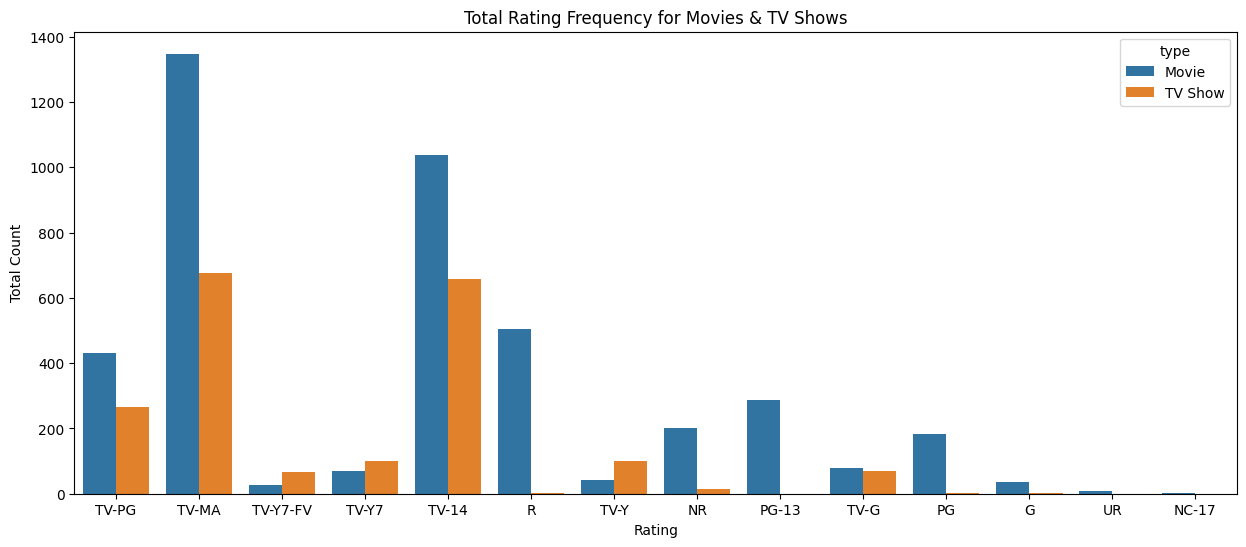

In [52]:
#1. Total count by ratings as a countplot.

total_count = df['rating'].value_counts()
#print(total_count)

#countplot
plt.figure(figsize=(15,6))
sns.countplot(x='rating',data=df,hue='type')
plt.xlabel("Rating")
plt.ylabel("Total Count")
plt.title("Total Rating Frequency for Movies & TV Shows")
plt.show()

In [ ]:
#2. Duration Distribution for Netflix movies as a Distplot.



In [27]:
movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_name,Content_age,movie_duration_minutes
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019,September,0,90
1,80117401,Movie,Jandino: Whatever it Takes,no director,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016,September,0,94
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017,September,0,99
6,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada",2017-09-08,2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f...",2017,September,3,110
7,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,2017-09-08,2017,TV-MA,60 min,Stand-Up Comedy,Fabrizio Copano takes audience participation t...,2017,September,0,60
